# Getting Started: Parameter Estimation Basics

The goal of parameter estimation is to estimate values for 
a vector, $\boldsymbol{\theta}$, from experimental data (observations) to use in the functional form:

$$
   \boldsymbol{y}_i = \boldsymbol{f}\left(\boldsymbol{x}_{i}, \boldsymbol{\theta}\right) +
    \boldsymbol{\varepsilon}_i \quad \forall \; i \in \{1, \ldots, n\}
$$

where $\boldsymbol{y}_{i} \in \mathbb{R}^m$ are observations of the measured or output variables,
$\boldsymbol{f}$ is the model function, $\boldsymbol{x}_{i} \in \mathbb{R}^{q}$ are the decision
or input variables, $\boldsymbol{\theta} \in \mathbb{R}^p$ are the model parameters,
$\boldsymbol{\varepsilon}_{i} \in \mathbb{R}^m$ are the measurement errors, and $n$ is the number of
experiments.

The following least squares objective can be used to estimate parameter
values assuming that the measurement errors follow a Gaussian distribution:

$$
   \min_{\boldsymbol{\theta}} \, g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta})
$$

where $g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta})$ can be:

1. $\textbf{Sum of squared errors}$
   
   If the measurement errors (which are assumed to follow a Gaussian distribution) are independent and
   identically distributed, the objective function can be defined as the sum of squared errors

$$
   g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta}) =
    \sum_{i = 1}^{n} \left(\boldsymbol{y}_{i} - \boldsymbol{f}(\boldsymbol{x}_{i};\boldsymbol{\theta})
    \right)^\text{T} \left(\boldsymbol{y}_{i} - \boldsymbol{f}(\boldsymbol{x}_{i};\boldsymbol{\theta})\right)
$$

2. $\textbf{Weighted sum of squared errors}$
   
   When the measurement errors are correlated and their covariance matrix, $\boldsymbol{\Sigma}_{\boldsymbol{y}}$,
   is known a priori, the objective function is defined as the weighted sum of squared errors
    
$$
   g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta}) =
    \frac{1}{2} \sum_{i = 1}^{n} \left(\boldsymbol{y}_{i} - \boldsymbol{f}(\boldsymbol{x}_{i};\boldsymbol{\theta})
    \right)^\text{T} \boldsymbol{\Sigma}_{\boldsymbol{y}}^{-1} \left(\boldsymbol{y}_{i} -
    \boldsymbol{f}(\boldsymbol{x}_{i};\boldsymbol{\theta})\right)
$$

Custom objectives can also be defined for parameter estimation.

In the applications of interest to us, the function $g(\cdot)$ is
usually defined as an optimization problem with a large number of
(perhaps constrained) optimization variables, a subset of which are
fixed at values $\boldsymbol{x}$ when the optimization is performed.
In other applications, the values of $\boldsymbol{\theta}$ are fixed
parameter values, but for the problem formulation above, the values of
$\boldsymbol{\theta}$ are the primary optimization variables. Note that in
general, the function $g(\cdot)$ will have a large set of
parameters that are not included in $\boldsymbol{\theta}$.

## Import the packages needed for the TC Lab parameter estimation

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load and explore the experimental data for the two-state model

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df[['Time', 'T1', 'Q1', 'Q2']].head() # the Q2 column entries are 0 because 
                                      # we are considering the two-state model

,Time,T1,Q1,Q2
0,0.00,22.2,50,0
1,1.01,22.2,51,0
2,2.01,22.2,52,0
3,3.00,22.2,53,0
4,4.01,22.2,54,0


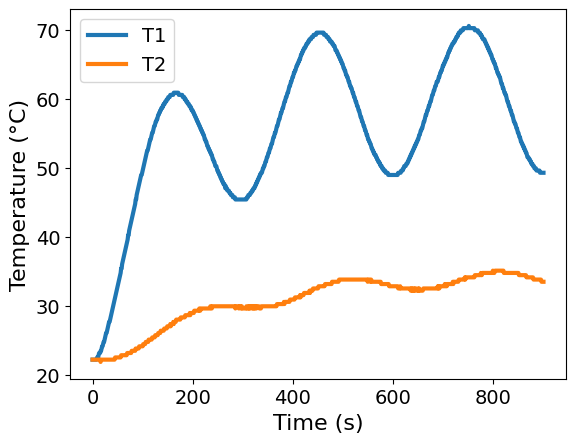

In [3]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

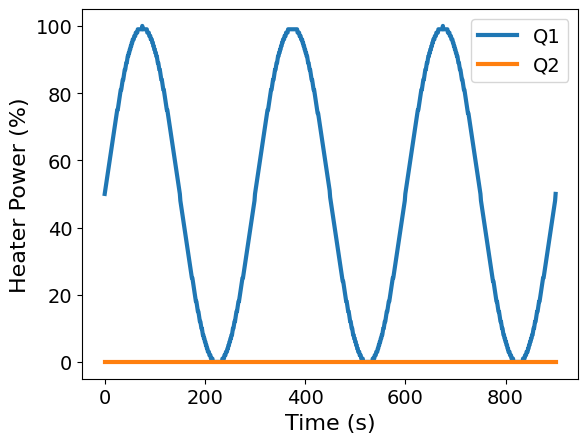

In [4]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

## Store in Custom Data Class 

In the file `tclab_pyomo.py`, we defined a `dataclass` for convenience. It is 
essentially a light weight container to store experimental data.

In [5]:
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

In [6]:
tc_data.to_data_frame().iloc[:, :4].head()

,time,T1,u1,P1
0,0.00,22.2,50,200
1,1.01,22.2,51,200
2,2.01,22.2,52,200
3,3.00,22.2,53,200
4,4.01,22.2,54,200


## TC Lab parameter estimation problem statement

We seek to estimate the heat transfer parameters, $C_p^H$, $C_p^S$, $U_a$, and $U_b$ from 
the sensor temperature data outlined above.

The predictions of the sensor temperature are obtained from the following model structure:

$$
\begin{align*}
C_p^H \frac{dT_H}{dt} & = U_a (T_{amb} - T_H) + U_c (T_S - T_H) + \alpha P u(t)\\
C_p^S \frac{dT_S}{dt} & = - U_b (T_S - T_H)
\end{align*}
$$
$$
\begin{align*}
\text{control input data}\qquad u(t_i) & = \bar{u}_{i}, \forall i \in \mathcal{T}
\\
\text{initial condition}\qquad T_H(t_0) & = T_{amb} \\
\text{initial condition}\qquad T_S(t_0) & = T_{amb}
\end{align*}
$$

where $T_{H}$ and $T_{S}$ are the heater and sensor temperatures in $^{\circ} \text{C}$, 
respectively, $T_{amb}$ is the ambient temperature in $^{\circ} \text{C}$, $C_p^H$ and 
$C_p^S$ are the heat capacity of the heater and sensor in $\text{J}/^{\circ} \text{C}$, 
respectively, $U_{a}$ and $U_{b}$ are the heat transfer coefficients from the heater to the 
sensor and the sensor to ambient (in $\text{W}/^{\circ} \text{C}$), respectively, $P$ is the 
maximum power limit in $\text{bit}$, $u$ is the heater power in $\%$, and $\alpha$ is 
constant that converts the unit of $P u(t)$ into $\text{W}$.

In the `tclab_pyomo.py` model, we defined several helper functions:
* `extract_results` takes a Pyomo model and returns the results stored in an instance of
  the `TC_Lab_data` dataclass.
* `extract_plot_results` takes experimental data (stored in a `TC_Lab_data` instance) and
  a Pyomo model. The function then generates plots showing the data and model predictions.
* `results_summary` summarizes the Pyomo.DoE results. We'll use this later in the workshop.

## Parameter estimation with ParmEst

In `ParmEst`, the TC Lab parameter estimation problem can be solved using two objective 
functions as mentioned in the introduction of this page:
* Sum of squared errors (SSE)
* Weighted sum of squared errors (WSSE)

Custom objectives may also be constructed and used to estimate the model parameters; 
however, uncertainty quantification for such objective is not supported.

### Step 0: Import ParmEst

In [7]:
import pyomo.contrib.parmest.parmest as parmest

### Step 1: Create a TC Lab experiment object

In [8]:
# define an Experiment object within ParmEst
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

### Step 2: Estimate parameters with the SSE objective

Since everything has been labeled properly in the Experiment object, we simply invoke 
ParmEst's Estimator function to estimate the parameters using the SSE objective.

In [9]:
pest_SSE = parmest.Estimator([TC_Lab_sine_exp, ], 
                             obj_function='SSE', tee=True)

obj_SSE, theta_SSE = pest_SSE.theta_est()

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

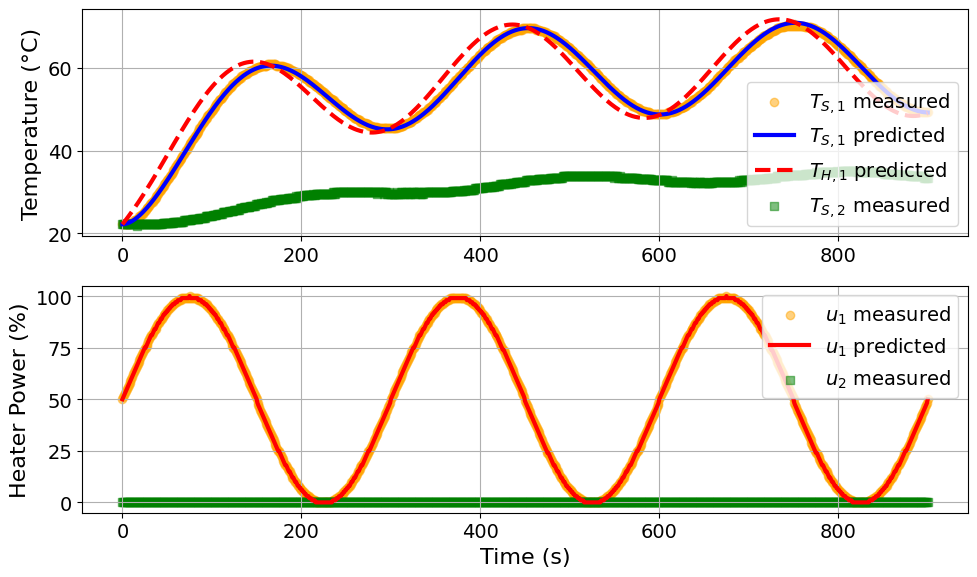

Model parameters:
Ua = 0.0417 Watts/degC
Ub = 0.0163 Watts/degC
CpH = 5.8757 Joules/degC
CpS = 0.3035 Joules/degC
 


In [10]:
# visualize the SSE results
parmest_regression_results = extract_plot_results(
    tc_data, pest_SSE.ef_instance.exp_scenarios[0]
)

### Step 2 (Optional): Use WSSE for weighted parameter estimation

The WSSE objective falls naturally from the likelihood function of a Gaussian distribution that is 
not necessarily independent and identically distributed. In the WSSE, the difference between the model 
predictions and the data are scaled by the measurement error. For this reason, the WSSE serve as the most 
appropriate objective function for heterogeneous data with variables in different units of measure or magnitudes.

In [11]:
pest_WSSE = parmest.Estimator([TC_Lab_sine_exp, ], 
                              obj_function='SSE_weighted', tee=True)

obj_WSSE, theta_WSSE = pest_WSSE.theta_est()

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

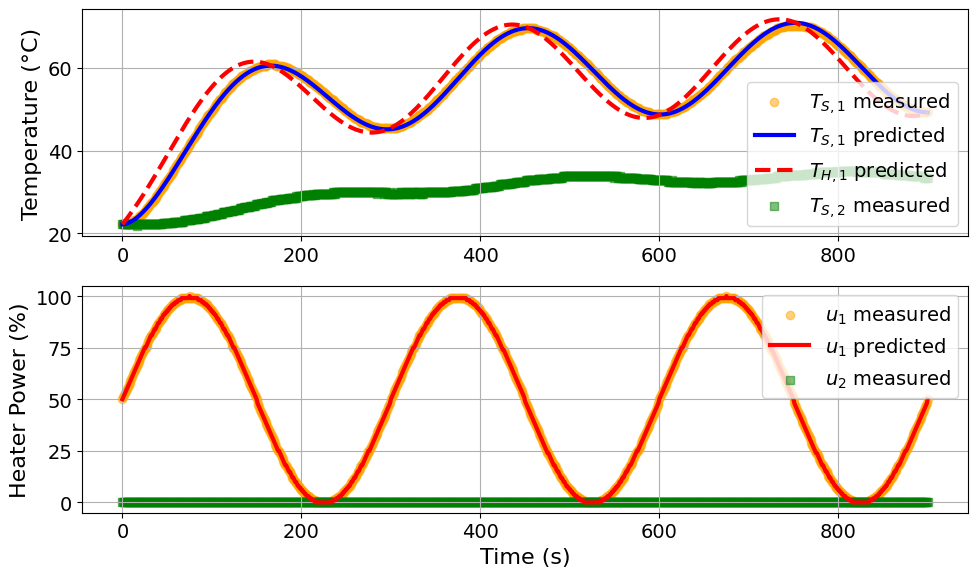

Model parameters:
Ua = 0.0417 Watts/degC
Ub = 0.0171 Watts/degC
CpH = 5.8582 Joules/degC
CpS = 0.3187 Joules/degC
 


In [12]:
# visualize the WSSE results
WSSE_parmest_regression_results = extract_plot_results(
    tc_data, pest_WSSE.ef_instance.exp_scenarios[0]
)

### Compare the parameter estimates from SSE and WSSE

In [13]:
theta_values_SSE = {k: round(val, 4) for k, val in theta_SSE.items()}
print("Estimated parameters using SSE objective:\n", theta_values_SSE)

theta_values_WSSE = {k: round(val, 4) for k, val in theta_WSSE.items()}
print("\nEstimated parameters using WSSE objective:\n", theta_values_WSSE)

Estimated parameters using SSE objective:
 {'Ua': 0.0417, 'Ub': 0.0163, 'inv_CpH': 0.1702, 'inv_CpS': 3.2951}

Estimated parameters using WSSE objective:
 {'Ua': 0.0417, 'Ub': 0.0171, 'inv_CpH': 0.1707, 'inv_CpS': 3.1379}


### Activity

In this activity, you will explore how measurement error assumptions influence parameter estimation results 
using the WSSE objective.

In [14]:
# define the measurement errors
meas_error = [0.1, 0.5, 1]

In [15]:
# define a list to store the result of the various measurement errors
activity_results_list = []

# for each of the measurement errors, estimate the parameters using ParmEst
for error in meas_error:
    # create a TC Lab experiment object
    exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states, 
                            measurement_error=error)

    # create a ParmEst Estimator object
    pest = parmest.Estimator([exp], obj_function='SSE_weighted', tee=False)

    # estimate the parameters
    obj, theta_raw = pest.theta_est()
    theta = {"Ua (W/°C)": round(theta_raw["Ua"], 4), 
             "Ub (W/°C)": round(theta_raw["Ub"], 4),
             "inv_CpH (°C/J)": round(theta_raw["inv_CpH"], 4),
             "inv_CpS (°C/J)": round(theta_raw["inv_CpS"], 4),
            }

    # add the measurement error associated with the parameter estimates
    theta["Measurement Error (°C)"] = error

    # update the list that stores the result of the various measurement errors
    activity_results_list.append(theta)

In [16]:
# store the activity results in a dataframe
activity_results_df = pd.DataFrame(activity_results_list).set_index("Measurement Error (°C)")

# visualize the results
display(activity_results_df)

,Ua (W/°C),Ub (W/°C),inv_CpH (°C/J),inv_CpS (°C/J)
Measurement Error (°C),,,,
0.1,0.0417,0.0159,0.1699,3.3932
0.5,0.0417,0.0172,0.1708,3.1201
1.0,0.0417,0.0171,0.1707,3.1372


### Takeaways from the activity

1. Uniform measurement error has limited impact on parameter estimates

   When the same measurement error is applied across all data points, the WSSE objective is rescaled,
   and the estimated parameters remain largely unchanged.
2. Small variations in the parameter estimates from SSE and WSSE (e.g., Ub and inv_CpS) can still occur
   from the choice of measurement error due to:
   * Numerical solver tolerances
   * Slight differences in convergence behavior
   * Sensitivity of certain parameters to scaling